# Rough likelihoods break gradient samplers — $d=1$

The true target is $N(0, 1)$ with log-density $L(\theta) = -\tfrac12\theta^2$. The sampler instead sees a deterministic, sinusoidally **perturbed** log-density

$$\log\pi(\theta) = -\tfrac12\theta^2 + A\,\sin(\omega\theta),$$

with gradient the exact path derivative. Because the perturbation is bounded, $\exp(\log\pi)$ is a proper density, but its stationary law differs from $N(0,1)$. So the divergence-to-truth captures **both** the perturbation bias **and** the sampler pathology induced by the rough gradient. We grid-search NUTS and WALNUTS (the latter is the kernel from the `DanWaxman/blackjax` fork) over $(A,\omega)$ and compare.

In [1]:
import time
import warnings

warnings.filterwarnings("ignore")

import arviz as az
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from tqdm import tqdm

import manual_gaussian_inference as mgi

%matplotlib inline

DIM = 1
NUM_WARMUP = 2000
NUM_SAMPLES = 5000
N_REPS = 3

In [2]:
# "Data" / ground truth: iid draws from the true N(0, 1).
system_truth = mgi.make_perturbed_gaussian_system(DIM)
truth = mgi.simulate_true_samples(jr.PRNGKey(0), system_truth, 2000)
reference = mgi.simulate_true_samples(jr.PRNGKey(1), system_truth, 50_000)

## Likelihood under a few $(A, \omega)$

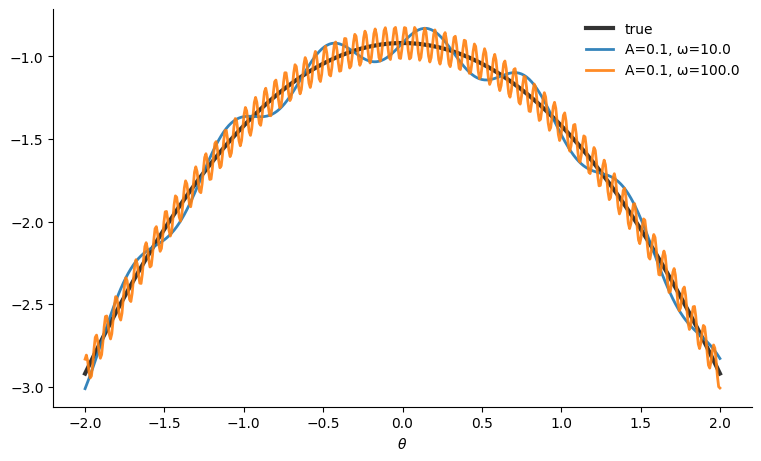

In [3]:
grid = jnp.linspace(-2.0, 2.0, 500)
settings = [(0.1, 10.0), (0.1, 100.0)]
true_curve = jax.vmap(lambda t: mgi.true_log_density(system_truth, t[None]))(grid)
curves, labels = [], []
for a_val, w_val in settings:
    system = mgi.make_perturbed_gaussian_system(DIM, a_val, w_val)
    curves.append(jax.vmap(lambda t: mgi.perturbed_log_density(system, t[None]))(grid))
    labels.append(f"A={a_val}, \u03c9={w_val}")
fig, ax = mgi.plot_likelihood_curves(grid, true_curve, curves, labels=labels)
plt.show()

## Grid search over $(A, \omega)$

Each cell averages W1-to-truth and ESS/s over 5 independent runs, for NUTS and WALNUTS.

In [4]:
a_grid = np.logspace(-5.0, -1.0, 5, base=10)
omega_grid = np.linspace(5.0, 500.0, 10)

In [5]:
def ess_min(samples):
    """Minimum effective sample size across coordinates (worst direction)."""
    arr = np.asarray(samples)
    return min(float(np.asarray(az.ess(arr[None, :, d]))) for d in range(arr.shape[1]))


def run_repeated(sampler, logdensity_fn, divergence_fn):
    """Run a sampler over N_REPS seeds; return (mean divergence, mean ESS/s, pooled
    samples). Wall-clock per run is end-to-end (JAX compile + warmup + sampling)."""
    divs, ess_rates, pooled = [], [], []
    for rep in range(N_REPS):
        t0 = time.perf_counter()
        result = sampler(
            logdensity_fn, rep, dim=DIM,
            num_warmup=NUM_WARMUP, num_samples=NUM_SAMPLES,
        )
        samples = np.asarray(jax.block_until_ready(result["samples"]))
        dt = time.perf_counter() - t0
        divs.append(divergence_fn(samples))
        ess_rates.append(ess_min(samples) / dt)
        pooled.append(samples)
    return float(np.mean(divs)), float(np.mean(ess_rates)), np.concatenate(pooled, 0)

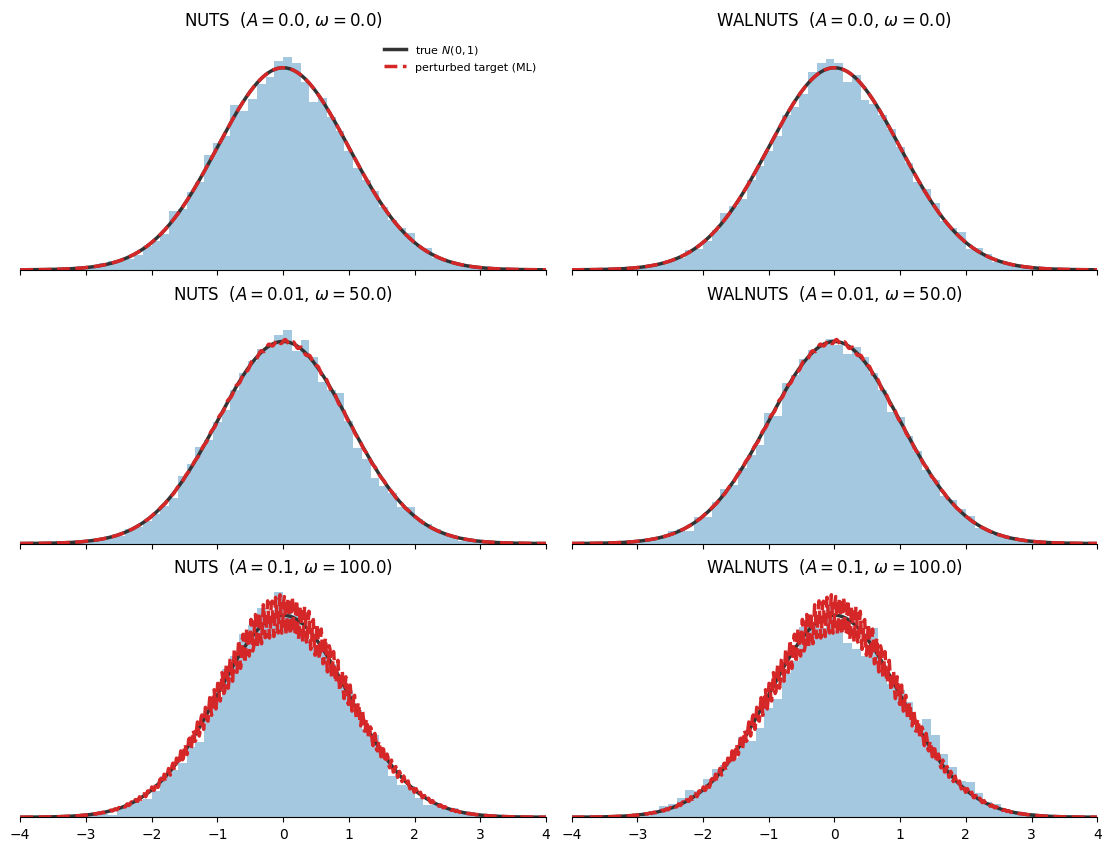

In [6]:
import jax

cases = [(0.0, 0.0), (1e-2, 50.0), (1e-1, 100.0)]
grid = jnp.linspace(-4.0, 4.0, 600)
grid_np = np.asarray(grid)
true_pdf = norm.pdf(grid_np)
bins = np.linspace(-4.0, 4.0, 61)

fig, axes = plt.subplots(
    len(cases),
    2,
    figsize=(11, 2.8 * len(cases)),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for row, (A, omega) in enumerate(cases):
    final_system = mgi.make_perturbed_gaussian_system(DIM, A, omega)
    final_logdensity = mgi.make_blackjax_logdensity(final_system, mode="perturbed")

    # Perturbed target as a normalized density over the grid (the "ML" curve the
    # sampler actually targets). For A=0 it coincides with the true N(0, 1).
    log_pert = np.asarray(
        jax.vmap(lambda t: mgi.perturbed_log_density(final_system, t[None]))(grid)
    )
    dens = np.exp(log_pert - log_pert.max())
    pert_pdf = dens / np.trapezoid(dens, grid_np)

    _, _, nuts_final = run_repeated(
        mgi.run_blackjax_nuts, final_logdensity, lambda s: 0.0
    )
    _, _, walnuts_final = run_repeated(mgi.run_walnuts, final_logdensity, lambda s: 0.0)

    for ax, samples, name in (
        (axes[row, 0], nuts_final, "NUTS"),
        (axes[row, 1], walnuts_final, "WALNUTS"),
    ):
        ax.hist(
            np.asarray(samples).ravel(), bins=bins, density=True, color="C0", alpha=0.4
        )
        ax.plot(grid_np, true_pdf, color="0.2", linewidth=2.5, label="true $N(0,1)$")
        ax.plot(
            grid_np,
            pert_pdf,
            color="C3",
            linewidth=2.5,
            linestyle="--",
            label="perturbed target (ML)",
        )
        ax.set_title(f"{name}  ($A={A}$, $\\omega={omega}$)")
        ax.set_yticks([])
        for side in ("top", "right", "left"):
            ax.spines[side].set_visible(False)

axes[0, 0].set_xlim(-4.0, 4.0)
axes[0, 0].legend(loc="upper right", frameon=False, fontsize=8)
plt.show()


In [7]:
n_a, n_w = len(a_grid), len(omega_grid)
div_nuts = np.full((n_a, n_w), np.nan)
div_walnuts = np.full((n_a, n_w), np.nan)
ess_nuts = np.full((n_a, n_w), np.nan)
ess_walnuts = np.full((n_a, n_w), np.nan)
divergence_fn = lambda s: mgi.wasserstein1_to_truth(s, reference)

for i_a in tqdm(range(n_a)):
    for j_w in tqdm(range(n_w), leave=False):
        system = mgi.make_perturbed_gaussian_system(
            DIM, float(a_grid[i_a]), float(omega_grid[j_w])
        )
        logdensity_fn = mgi.make_blackjax_logdensity(system, mode="perturbed")
        div_nuts[i_a, j_w], ess_nuts[i_a, j_w], _ = run_repeated(
            mgi.run_blackjax_nuts, logdensity_fn, divergence_fn
        )
        div_walnuts[i_a, j_w], ess_walnuts[i_a, j_w], _ = run_repeated(
            mgi.run_walnuts, logdensity_fn, divergence_fn
        )

100%|██████████| 5/5 [04:11<00:00, 50.35s/it]


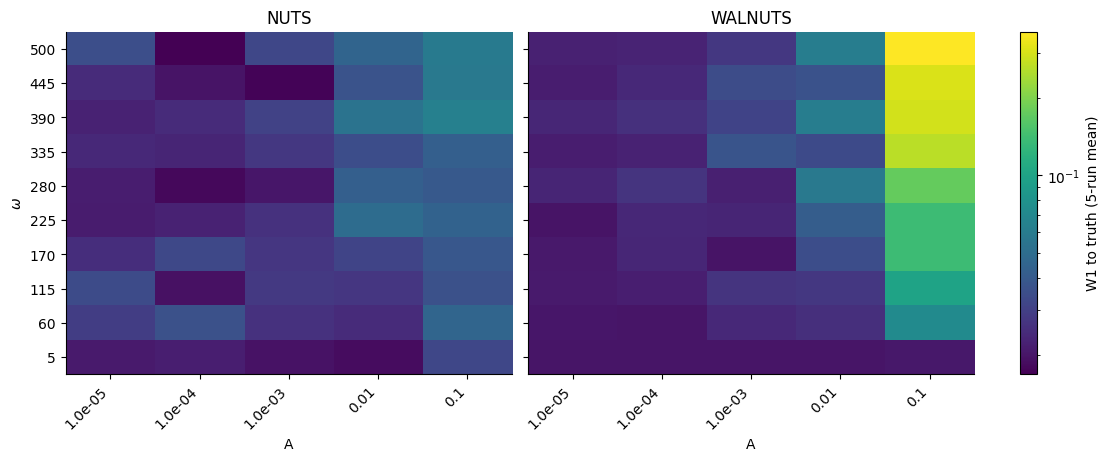

In [8]:
fig, _ = mgi.plot_nuts_walnuts_heatmaps(
    a_grid, omega_grid, div_nuts, div_walnuts,
    quantity_label="W1 to truth (5-run mean)", log_color=True,
)
plt.show()

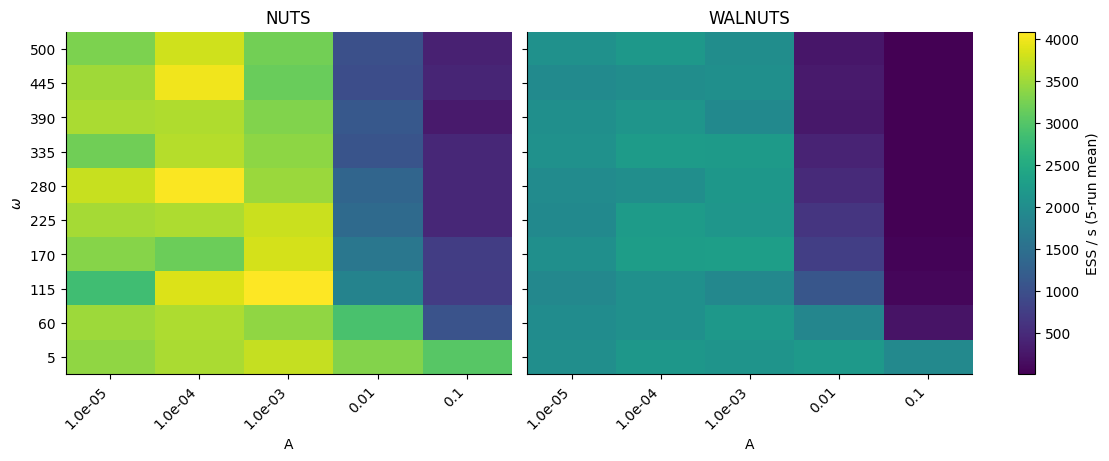

In [9]:
fig, _ = mgi.plot_nuts_walnuts_heatmaps(
    a_grid, omega_grid, ess_nuts, ess_walnuts,
    quantity_label="ESS / s (5-run mean)", log_color=False,
)
plt.show()